# Corridas de Táxi em Chicago

Análise de corridas de táxi em Chicago com dados extraídos por SQL. O estudo levanta as empresas com maior volume de viagens e os bairros de destino mais frequentes, e testa se a chuva altera a duração das corridas do Loop para o aeroporto O'Hare aos sábados.

In [1]:
# Importando bibliotecas relevantes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st

In [2]:
# Lendo os arquivos de dados
df_companies = pd.read_csv('/datasets/project_sql_result_01.csv')
df_bairros = pd.read_csv('/datasets/project_sql_result_04.csv')

In [3]:
# Visualizando os dados do df_trips
print(df_companies.info())
df_companies.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
None


,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasing,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299
5,Chicago Carriage Cab Corp,9181
6,City Service,8448
7,Sun Taxi,7701
8,Star North Management LLC,7455
9,Blue Ribbon Taxi Association Inc.,5953


O dataframe companies não apresenta valores ausentes, podemos ver que tem 64 linhas de 0 a 63 e 64 valores não nulos. Os tipos de dados também estão corretos, company_name é uma string, portanto object e trips_amount representa quantidade de viagens que está corretamente como int.

In [4]:
# Visualizando os dados do df_bairros
print(df_bairros.info())
df_bairros.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB
None


,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000


O dataframe bairros não apresenta valores ausentes, podemos ver que tem 94 linhas de 0 a 93 e 94 valores não nulos. Os tipos de dados também estão corretos, dropoff_location_name é uma string, portanto object e average_trips representa quantidade média de viagens que está corretamente como float.

In [5]:
# Encontrando os 10 principais bairros como destinos
top10_bairros = df_bairros.sort_values(by='average_trips',ascending=False).head(10)
top10_bairros

,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000
5,Lake View,2420.966667
6,Grant Park,2068.533333
7,Museum Campus,1510.000000
8,Gold Coast,1364.233333
9,Sheffield & DePaul,1259.766667


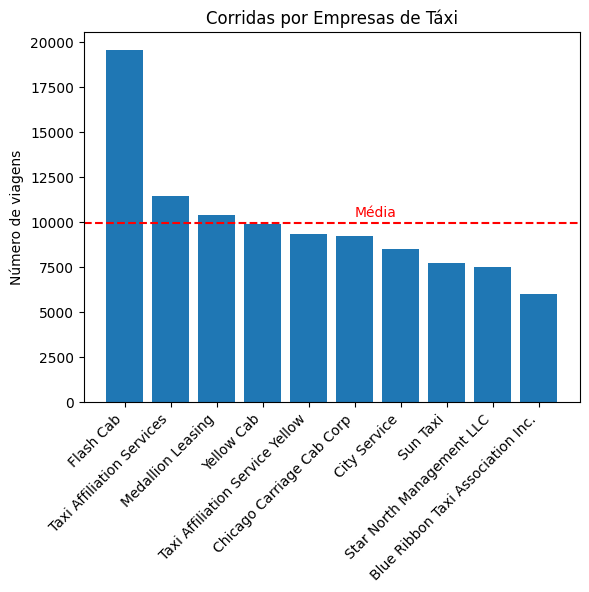

In [6]:
# Criando gráficos para facilitar a visualização

# Gráfico de empresas de Táxi por número de corridas
# Limitando número de empresas para facilitar visualização 
top10_companies = df_companies.sort_values(by='trips_amount', ascending=False).head(10)
top10_average = top10_companies['trips_amount'].mean()
# Criando gráfico
plt.bar(top10_companies['company_name'], top10_companies['trips_amount'])
plt.title('Corridas por Empresas de Táxi')
plt.ylabel('Número de viagens')
plt.xticks(rotation=45, ha='right')
# Criando uma linha de referência
plt.axhline(y=top10_average, color='red', linestyle='--')
plt.text(x=5, y=top10_average + 400, s='Média', color='red')
plt.show()

Analisando o gráfico a empresa Flash Cab parece ser a favorita dos passageiros de Chicago. Ao visualizarmos a média de corridas, podemos ver que apenas 3 empresas ficam acima dessa faixa, isso ocorre porque Flash Cab apresenta um número de viagens bem maior que seus concorrentes, mais de 8000 viagens de diferença para o segundo colocado Taxi Affiliation Services.

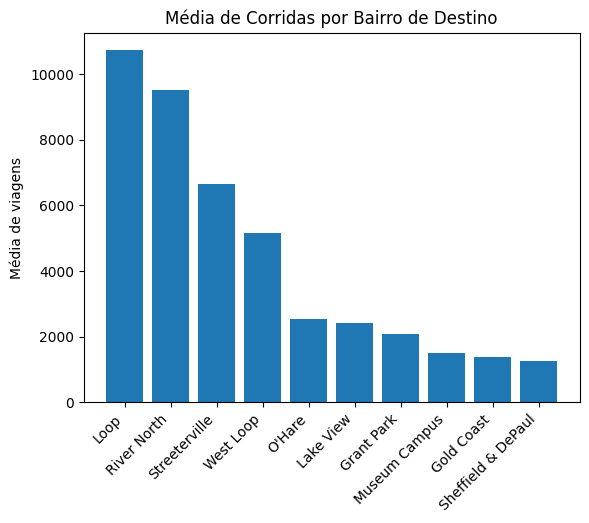

In [7]:
# Gráfico de bairro de destino
plt.bar(top10_bairros['dropoff_location_name'], top10_bairros['average_trips'])
plt.title('Média de Corridas por Bairro de Destino')
plt.ylabel('Média de viagens')
plt.xticks(rotation=45, ha='right')
plt.show()

Analisando o gráfico podemos ver que existe uma grande diferença entre os 10 maiores destinos. O top10 apresenta uma divisão clara entre os 4 mais visitados e os demais. Isso ocorre possivelmente pois o Loop é o coração financeiro, histórico e cultural da cidade e os bairros de River North, Streeterville e West Loop são seus vizinhos. Isso indica que a média de corridas é um reflexo direto do interesse das pessoas na área.

# Testando hipóteses
Nesta etapa, avaliaremos o impacto do clima no tempo de deslocamento. O objetivo é testar se a duração média das viagens do Loop para o Aeroporto Internacional O'Hare apresenta uma alteração significativa em sábados chuvosos, para isso aplicaremos um ttest. Comparando o resultado do teste a um nível de significância de 5%, teremos uma representação estatística do impacto do clima no tempo de viagem.

In [8]:
# Importando o dataset 
rain_saturday= pd.read_csv('/datasets/project_sql_result_07.csv')
rain_saturday.info()
rain_saturday.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB


,start_ts,weather_conditions,duration_seconds
0,2017-11-25 16:00:00,Good,2410.0
1,2017-11-25 14:00:00,Good,1920.0
2,2017-11-25 12:00:00,Good,1543.0
3,2017-11-04 10:00:00,Good,2512.0
4,2017-11-11 07:00:00,Good,1440.0


O dataframe está completo, com 1068 linhas numeradas de 0 a 1067 com 1068 valores não nulos. A coluna start_ts não está no tipo datetime, mas considerando o objetivo a ser estudado,apenas as colunas weather_conditions e duration_seconds serão utilizadas e seus tipos estão corretos.

### Hipótese Nula (H0):
    A duração média dos passeios do Loop para o Aeroporto Internacional O'Hare não muda nos sábados chuvosos.
### Hipótese Alternativa (H1):
    A duração média dos passeios do Loop para o Aeroporto Internacional O'Hare muda nos sábados chuvosos.

In [9]:
# Separando os conjuntos relevantes
good_weather = rain_saturday[rain_saturday['weather_conditions']=='Good']['duration_seconds']
bad_weather = rain_saturday[rain_saturday['weather_conditions']=='Bad']['duration_seconds']

# Definindo nível de significância
alpha = 0.05

# Aplicar o teste t
results = st.ttest_ind(good_weather, bad_weather,equal_var=False)
p_value = results.pvalue
statistic = results.statistic

# Compartilhando resultado
print(f"Estatística do teste: {statistic:.4f}")
print(f"Valor p: {p_value:.2e}")
print()

# Interpretação do resultado
if p_value < alpha:
    print(f"Resultado: Rejeitamos H₀ (p-value = {p_value:.6f} < alpha = {alpha})")
    print("Conclusão: Existe diferença significativa entre a duração média dos passeios do Loop para o Aeroporto Internacional de O'Hare nos sábados chuvosos")
else:
    print(f"Resultado: Não rejeitamos H₀ (p-value = {p_value:.6f} ≥ alpha = {alpha})")
    print("Conclusão: Não existe diferença significativa entre a duração média dos passeios do Loop para o Aeroporto Internacional de O'Hare nos sábados chuvosos")
print()
print("=== ESTATÍSTICAS DESCRITIVAS ===")
print(f"Duração média clima bom: {good_weather.mean():.2f}s")
print(f"Duração média clima chuvoso: {bad_weather.mean():.2f}s")
print(f"Diferença: {good_weather.mean() - bad_weather.mean():.2f}s")

Estatística do teste: -7.1860
Valor p: 6.74e-12

Resultado: Rejeitamos H₀ (p-value = 0.000000 < alpha = 0.05)
Conclusão: Existe diferença significativa entre a duração média dos passeios do Loop para o Aeroporto Internacional de O'Hare nos sábados chuvosos

=== ESTATÍSTICAS DESCRITIVAS ===
Duração média clima bom: 1999.68s
Duração média clima chuvoso: 2427.21s
Diferença: -427.53s


Os testes permitem concluir que a chuva aumenta significativamente o tempo de viagem do Loop para o Aeroporto O'Hare aos sábados.

 O valor-p de 6.74e-12 (menor que o alpha de 0.05) rejeita a hipótese nula de que as médias são iguais. A diferença não é um mero acaso.
 
 Impacto Prático: 
 
 * Sábado com clima bom: ~33,3 minutos (1999,68s)
 
 * Sábado chuvoso: ~40,4 minutos (2427,21s)
 
 Na prática, a chuva adiciona, em média, 7,1 minutos (ou um aumento de cerca de 21%) ao tempo de deslocamento para o aeroporto.